#Neural Network - A Simple Perceptron
Assignment Code: DS-AG-019

Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.
- Deep Learning is a subfield of machine learning that uses artificial neural networks with many layers (deep neural networks) to automatically learn complex patterns and representations from large amounts of data.

- Evolution of Deep Learning:

    - Artificial Neural Networks (1950s-1980s): Inspired by the human brain (e.g., perceptron). Limited by low computational power and small datasets.
    - Backpropagation (1980s-1990s) : Enabled training of multi-layer networks, but deep models still struggled due to vanishing gradients and hardware constraints.
    - Revival in the (2000s-2010s) :
      - Availability of large datasets
      - Powerful GPUs
      - Improved algorithms (ReLU, dropout, batch normalization) Led to breakthroughs in image recognition, speech recognition, and NLP.
---

Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?
- A Perceptron is the simplest artificial neural network model used for binary classification. Its basic architecture consists of an input layer where multiple input features are provided, each associated with a weight, a bias term, a summation unit, and an activation function. The perceptron computes a weighted sum of the inputs and bias, and this result is passed through an activation function, usually a step function, to produce a binary output. During training, the perceptron adjusts its weights based on the error between the predicted output and the actual output, enabling it to learn a decision boundary from the data.

- Limitaions -

However, the perceptron has significant limitations. It can only solve linearly separable problems, meaning it fails when classes cannot be separated by a straight line or hyperplane, such as in the XOR problem. Additionally, the use of a simple activation function restricts its ability to model complex patterns. Due to these limitations, single-layer perceptrons are not suitable for complex real-world tasks, leading to the development of multi-layer perceptrons and deep neural networks.

---

Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

- Activation functions play a crucial role in neural networks by introducing non-linearity into the model, allowing it to learn and represent complex patterns beyond simple linear relationships. Without activation functions, a neural network would behave like a linear model regardless of the number of layers, making it incapable of solving complex problems. Activation functions also control the output of neurons and influence how gradients flow during backpropagation, directly affecting learning efficiency and convergence.

The Sigmoid function maps input values to a range between 0 and 1, making it useful for probability-based outputs such as binary classification. However, it suffers from the vanishing gradient problem for large positive or negative inputs and is not zero-centered, which can slow down learning. The Tanh (hyperbolic tangent) function outputs values between −1 and 1 and is zero-centered, which often leads to faster convergence than Sigmoid, but it still experiences vanishing gradients for extreme input values. The ReLU (Rectified Linear Unit) function outputs zero for negative inputs and the input value itself for positive inputs, making it computationally efficient and reducing the vanishing gradient problem. However, ReLU can suffer from the “dying ReLU” issue, where neurons stop learning if they output zero consistently. Overall, Sigmoid and Tanh are commonly used in output or shallow layers, while ReLU is the most widely used activation function in hidden layers of deep neural networks.

---

Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.
- In neural networks, loss functions and cost functions are used to measure how well a model performs, but they differ in scope. A loss function measures the error for a single training example by comparing the model’s predicted output with the actual target value. It helps quantify how wrong the prediction is for one data point and guides weight updates during training. Common examples of loss functions include Mean Squared Error (MSE) for regression tasks and Binary Cross-Entropy (Log Loss) for binary classification.

A cost function, on the other hand, represents the overall error of the model across the entire dataset (or a batch of data). It is typically computed as the average or sum of individual loss values over all training samples. The cost function provides a global measure of model performance and is what optimization algorithms aim to minimize during training. For example, the average MSE over all training samples is a cost function, and the categorical cross-entropy averaged over a batch is commonly used in multi-class classification. In summary, the loss function operates at the individual sample level, while the cost function aggregates these losses to evaluate overall model performance.

---

Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.
- Optimizers play a vital role in neural networks by updating model parameters (weights and biases) in a way that minimizes the loss or cost function during training. They determine how the gradients computed through backpropagation are used to adjust parameters, directly affecting the speed of convergence, stability of training, and overall model performance. A good optimizer helps the network escape local minima, handle noisy gradients, and learn efficiently from data.

- Gradient Descent is the most basic optimization algorithm, where parameters are updated in the opposite direction of the gradient of the loss function with respect to the weights. While it is simple and effective, it can be slow to converge and is sensitive to the choice of learning rate. It also struggles with ravines and may get stuck in local minima. RMSprop improves upon Gradient Descent by adapting the learning rate for each parameter individually using a moving average of squared gradients. This helps stabilize training and works well for non-stationary and noisy data. Adam (Adaptive Moment Estimation) combines the advantages of RMSprop and momentum by maintaining both an exponentially decaying average of past gradients and squared gradients. As a result, Adam converges faster, requires less tuning, and is widely used in deep learning applications. Overall, Gradient Descent is conceptually simple, RMSprop offers adaptive learning rates, and Adam provides fast and robust convergence, making it the most popular choice in practice.

---


In [1]:
'''
Use NumPy, Matplotlib, and Tensorflow/Keras for implementation.
Question 6: Write a Python program to implement a single-layer perceptron from
scratch using NumPy to solve the logical AND gate.
(Include your Python code and output in the code box below.)
'''
import numpy as np

# AND gate input and output
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 0, 0, 1])  # AND gate output

# Initialize weights and bias
weights = np.random.rand(2)
bias = np.random.rand()
learning_rate = 0.1
epochs = 10

# Step activation function
def step_function(z):
    return 1 if z >= 0 else 0

# Training the perceptron
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}")
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        y_pred = step_function(z)
        error = y[i] - y_pred

        # Update weights and bias
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

        print(f"Input: {X[i]}, Predicted: {y_pred}, Actual: {y[i]}")

# Testing the trained perceptron
print("\nFinal Results:")
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    output = step_function(z)
    print(f"Input: {X[i]} -> Output: {output}")

Epoch 1
Input: [0 0], Predicted: 1, Actual: 0
Input: [0 1], Predicted: 1, Actual: 0
Input: [1 0], Predicted: 1, Actual: 0
Input: [1 1], Predicted: 1, Actual: 1
Epoch 2
Input: [0 0], Predicted: 1, Actual: 0
Input: [0 1], Predicted: 1, Actual: 0
Input: [1 0], Predicted: 1, Actual: 0
Input: [1 1], Predicted: 1, Actual: 1
Epoch 3
Input: [0 0], Predicted: 1, Actual: 0
Input: [0 1], Predicted: 1, Actual: 0
Input: [1 0], Predicted: 1, Actual: 0
Input: [1 1], Predicted: 1, Actual: 1
Epoch 4
Input: [0 0], Predicted: 0, Actual: 0
Input: [0 1], Predicted: 0, Actual: 0
Input: [1 0], Predicted: 1, Actual: 0
Input: [1 1], Predicted: 1, Actual: 1
Epoch 5
Input: [0 0], Predicted: 0, Actual: 0
Input: [0 1], Predicted: 0, Actual: 0
Input: [1 0], Predicted: 1, Actual: 0
Input: [1 1], Predicted: 0, Actual: 1
Epoch 6
Input: [0 0], Predicted: 0, Actual: 0
Input: [0 1], Predicted: 0, Actual: 0
Input: [1 0], Predicted: 1, Actual: 0
Input: [1 1], Predicted: 0, Actual: 1
Epoch 7
Input: [0 0], Predicted: 0, Actu

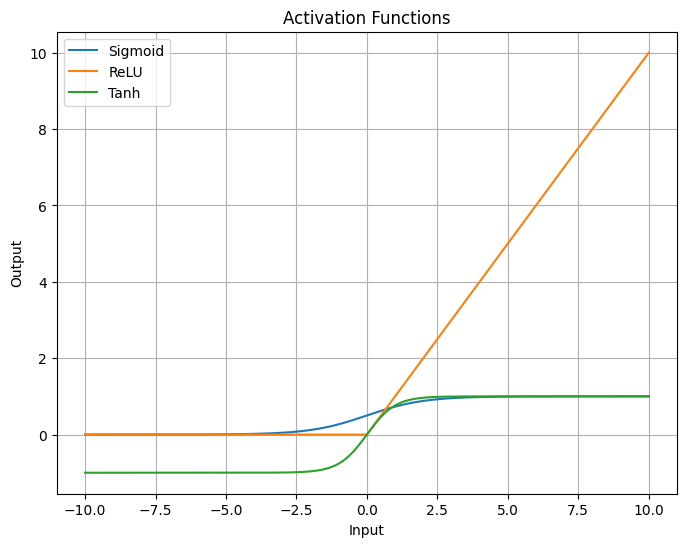

In [2]:
'''
Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions
using Matplotlib.

'''

import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 400)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Compute outputs
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

# Plot the activation functions
plt.figure(figsize=(8, 6))
plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_tanh, label='Tanh')

plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Activation Functions')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
'''
Question 8: Use Keras to build and train a simple multilayer neural network on the
MNIST digits dataset. Print the training accuracy.

'''
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build the model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

# Print training accuracy
train_accuracy = history.history['accuracy'][-1]
print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8701 - loss: 0.4390
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9652 - loss: 0.1124
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9785 - loss: 0.0689
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9832 - loss: 0.0538
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9866 - loss: 0.0401

Training Accuracy: 98.50%


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7776 - loss: 0.6388 - val_accuracy: 0.8493 - val_loss: 0.4130
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8632 - loss: 0.3766 - val_accuracy: 0.8693 - val_loss: 0.3636
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8786 - loss: 0.3325 - val_accuracy: 0.8680 - val_loss: 0.3627
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8834 - loss: 0.3101 - val_accuracy: 0.8694 - val_loss: 0.3668
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8915 - loss: 0.2918 - val_accuracy: 0.8676 - val_loss: 0.3656
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8985 - loss: 0.2717 - val_accuracy: 0.8615 - val_loss: 0.3659
Epoch 7/10
1875/1875 ━━━━━━━━━━━

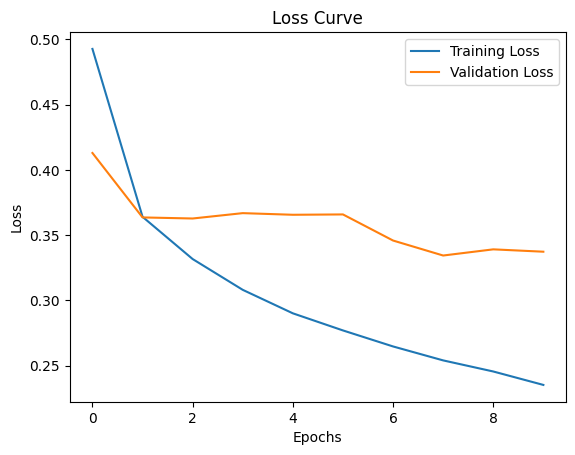

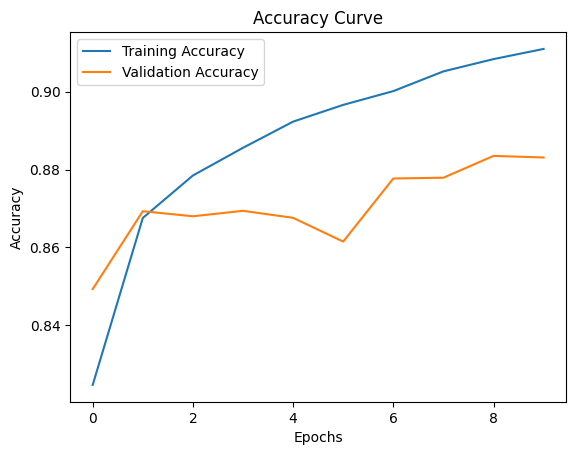

In [4]:
'''
Question 9: Visualize the loss and accuracy curves for a neural network model trained
on the Fashion MNIST dataset. Interpret the training behavior.

'''

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize data
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build the model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Plot Loss
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()


---
Question 10: You are working on a project for a bank that wants to automatically detect fraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate.
Explain your real-time data science workflow:
- How would you design a deep learning model (perceptron or multilayer NN)?
- Which activation function and loss function would you use, and why?
- How would you train and evaluate the model, considering class imbalance?
- Which optimizer would be suitable, and how would you prevent overfitting?

Solutions:

- Model Design: For fraud detection on large, structured, and imbalanced banking data, I would design a multilayer neural network (MLP) rather than a single-layer perceptron, as fraud patterns are complex and non-linear. The model would take structured inputs such as transaction amount, merchant ID (encoded), customer location, and historical behavior features. Multiple hidden layers with sufficient neurons would allow the network to learn complex relationships between features, while the output layer would have a single neuron for binary classification (fraudulent vs. legitimate).

- Activation and Loss Functions: I would use the ReLU activation function in the hidden layers because it is computationally efficient and helps mitigate the vanishing gradient problem, enabling faster and more stable training. For the output layer, a Sigmoid activation function would be appropriate since it outputs a probability between 0 and 1, which is ideal for binary classification. The Binary Cross-Entropy loss function would be used because it directly measures the error between predicted probabilities and actual binary labels, making it well-suited for fraud detection tasks.

- Training and Evaluation with Class Imbalance: To address class imbalance, I would apply techniques such as class weighting, oversampling minority (fraud) transactions, or undersampling the majority class. During training, class weights ensure the model penalizes misclassified fraud cases more heavily. For evaluation, I would avoid relying solely on accuracy and instead use metrics such as precision, recall, F1-score, and AUC-ROC, as correctly identifying fraudulent transactions (high recall) is more critical than overall accuracy in banking applications.

- Optimizer and Overfitting Prevention: The Adam optimizer would be a suitable choice due to its adaptive learning rate and fast convergence on large datasets. To prevent overfitting, I would use regularization techniques such as dropout layers, L2 weight regularization, and early stopping based on validation loss. Additionally, proper feature normalization and continuous model monitoring in real-time deployment would help maintain stable and reliable fraud detection performance.
---